# PCA — Why It Works

*Course notes for **Math for Machine Learning**, C1 · W4 · L2 · V08b — "PCA: Why It Works" (DeepLearning.AI).*

Why does projecting onto the **largest-eigenvalue** eigenvector capture the most variance? A full proof is beyond scope, but the **geometric intuition** is clear: viewing the covariance matrix $C$ as a **transformation**, it maps the unit circle to an **ellipse**, and its **major axis** — the direction of greatest stretch — is exactly the top eigenvector.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)
%matplotlib inline

C = np.array([[9, 4],
              [4, 3]])

## 1. The covariance matrix as a transformation

The covariance matrix $C = \begin{pmatrix} 9 & 4 \\ 4 & 3 \end{pmatrix}$ captures how spread out the data is. To *see* that spread, treat $C$ as a **change of basis** and ask how it transforms space:

$$ (1,0) \mapsto (9,4), \quad (0,1) \mapsto (4,3), \quad (-1,0) \mapsto (-9,-4), \quad (0,-1) \mapsto (-4,-3). $$

In [2]:
for v in [(1, 0), (0, 1), (-1, 0), (0, -1)]:
    print(f'{v} -> {C @ np.array(v)}')

(1, 0) -> [9 4]
(0, 1) -> [4 3]
(-1, 0) -> [-9 -4]
(0, -1) -> [-4 -3]


## 2. The unit circle becomes an ellipse

Apply $C$ to **every** direction on the unit circle (radius $1$, since we only care about *directions* of stretch). The circle maps to an **ellipse**: different directions get stretched by different amounts. The **major axis** — the longest direction of the ellipse — is the direction of **greatest stretch**, and it aligns with the top eigenvector.

eigenvalues (desc): [11.  1.]
top eigenvector (~ (2,1) direction): [1.  0.5]


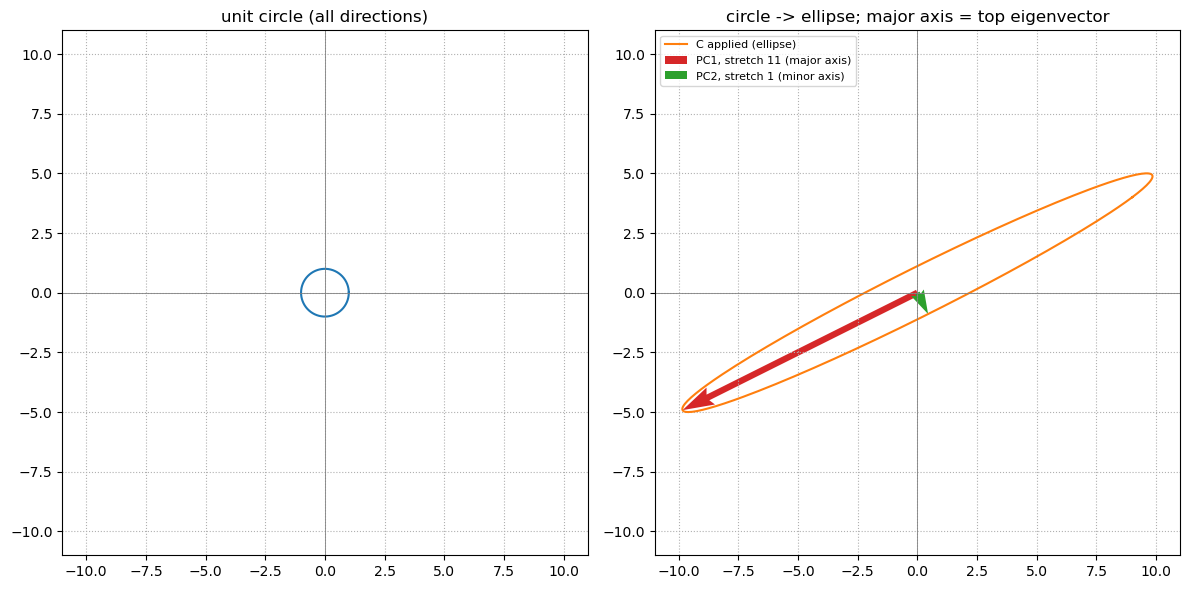

In [3]:
# eigen-decomposition (C is symmetric -> real eigenvalues, orthogonal eigenvectors)
vals, vecs = np.linalg.eigh(C)
order = np.argsort(vals)[::-1]
vals, vecs = vals[order], vecs[:, order]
print('eigenvalues (desc):', vals)                 # 11, 1
print('top eigenvector (~ (2,1) direction):', vecs[:, 0] / vecs[:, 0][np.argmax(np.abs(vecs[:, 0]))])

theta = np.linspace(0, 2*np.pi, 200)
circle = np.array([np.cos(theta), np.sin(theta)])   # 2 x 200
ellipse = C @ circle

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].plot(circle[0], circle[1], 'C0'); axes[0].set_title('unit circle (all directions)')
axes[0].set_xlim(-11, 11); axes[0].set_ylim(-11, 11)

ax = axes[1]
ax.plot(ellipse[0], ellipse[1], 'C1', label='C applied (ellipse)')
opts = dict(angles='xy', scale_units='xy', scale=1)
ax.quiver(0, 0, *(vecs[:, 0]*vals[0]), color='C3', width=0.012, **opts, label=f'PC1, stretch {vals[0]:.0f} (major axis)')
ax.quiver(0, 0, *(vecs[:, 1]*vals[1]), color='C2', width=0.012, **opts, label=f'PC2, stretch {vals[1]:.0f} (minor axis)')
ax.set_title('circle -> ellipse; major axis = top eigenvector'); ax.legend(fontsize=8, loc='upper left')
ax.set_xlim(-11, 11); ax.set_ylim(-11, 11)
for a in axes:
    a.axhline(0, color='gray', lw=0.6); a.axvline(0, color='gray', lw=0.6)
    a.set_aspect('equal'); a.grid(True, ls=':')
plt.tight_layout(); plt.show()

## 3. How much does each direction stretch?

From the **eigenbasis** viewpoint, $C$ is just two stretches:

- along the eigenvector $(2,1)$: stretched by its eigenvalue **$11$**,
- along the eigenvector $(-1,2)$: stretched by its eigenvalue **$1$**,
- **every other** direction stretches by something **between $1$ and $11$**.

We can measure a direction's stretch as the ratio $\|Cv\| / \|v\|$. Two examples from the lecture:

- $(0,1) \mapsto (4,3)$: norm $1 \to 5$, so stretched by **$5$**.
- $(1,0) \mapsto (9,4)$: norm $1 \to \sqrt{97} \approx 9.85$ — closer to the max, but still **less than $11$**.

In [4]:
def stretch(v):
    v = np.asarray(v, dtype=float)
    return np.linalg.norm(C @ v) / np.linalg.norm(v)

print('stretch of (0,1)  =', stretch([0, 1]))          # 5.0
print('stretch of (1,0)  =', round(stretch([1, 0]), 3)) # ~9.849
print('stretch of (2,1)  =', round(stretch([2, 1]), 3), ' (eigenvector -> eigenvalue 11, the max)')
print('stretch of (-1,2) =', round(stretch([-1, 2]), 3), ' (eigenvector -> eigenvalue 1, the min)')

stretch of (0,1)  = 5.0
stretch of (1,0)  = 9.849
stretch of (2,1)  = 11.0  (eigenvector -> eigenvalue 11, the max)
stretch of (-1,2) = 1.0  (eigenvector -> eigenvalue 1, the min)


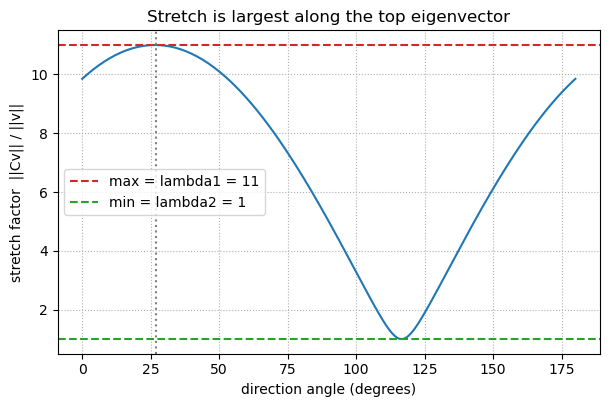

max stretch 11.00 at angle 27 deg, which points along the top eigenvector [1.  0.5]


In [5]:
# Stretch factor over all directions: bounded between the two eigenvalues
angles = np.linspace(0, np.pi, 181)
factors = np.array([stretch([np.cos(a), np.sin(a)]) for a in angles])
best_angle = angles[np.argmax(factors)]

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(np.degrees(angles), factors, color='C0')
ax.axhline(vals[0], color='C3', ls='--', label=f'max = lambda1 = {vals[0]:.0f}')
ax.axhline(vals[1], color='C2', ls='--', label=f'min = lambda2 = {vals[1]:.0f}')
ax.axvline(np.degrees(best_angle), color='gray', ls=':')
ax.set_xlabel('direction angle (degrees)'); ax.set_ylabel('stretch factor  ||Cv|| / ||v||')
ax.grid(True, ls=':'); ax.legend()
ax.set_title('Stretch is largest along the top eigenvector')
plt.show()
print(f'max stretch {factors.max():.2f} at angle {np.degrees(best_angle):.0f} deg,',
      f'which points along the top eigenvector {vecs[:,0]/vecs[:,0][np.argmax(np.abs(vecs[:,0]))]}')

## 4. Putting the intuition together

Chaining the three facts:

1. The covariance matrix $C$ **characterizes the spread** of your data.
2. Its **eigenvectors** are the directions in which $C$ acts as a pure **stretch**.
3. The **largest eigenvalue** marks the direction of **greatest stretch** — and every other direction stretches **less**.

Greatest stretch $=$ greatest **variance**. So projecting onto the eigenvectors with the **biggest eigenvalues** keeps the directions of **most variance** — exactly what PCA has been after all along.

## Summary

- Viewed as a transformation, the covariance matrix $C$ maps the **unit circle to an ellipse**; the ellipse's **major axis** is the direction of maximum stretch.
- In the **eigenbasis**, $C$ is pure stretching: eigenvalue $11$ along $(2,1)$, eigenvalue $1$ along $(-1,2)$, and every other direction stretches **between** these.
- The stretch factor $\|Cv\|/\|v\|$ is **maximized along the top eigenvector** (equal to its eigenvalue) — e.g. $(1,0)$ stretches by $9.85 < 11$.
- Therefore the **largest-eigenvalue eigenvectors are the directions of greatest variance**, which is precisely why PCA chooses them.